# Semantic Segmentation (PH2): Skin Lesion Masking

В этом проекте показан полный пайплайн семантической сегментации кожных поражений на датасете **PH2**: подготовка данных, обучение модели, оценка качества и визуализация предсказаний.

**Метрика:** IoU (Jaccard).  
**Модель:** SegNet (encoder–decoder) + сравнение loss-функций (BCE/Dice/Focal).  


## Setup

> Для воспроизводимости рекомендуется окружение с CUDA (опционально).  
> Зависимости: `torch`, `torchvision`, `torchmetrics`, `segmentation-models-pytorch`, `numpy`, `scikit-image`, `matplotlib`, `gdown`.

Если датасет уже скачан локально — пропустите следующий блок скачивания.


In [ ]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
get_ipython().system_raw("unrar x PH2Dataset.rar")

## Data loading & preprocessing

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

## Train/valid/test split & dataloaders

In [ ]:
import numpy as np
np.random.seed(42)
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [ ]:
from torch.utils.data import DataLoader
batch_size = 4
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size*2, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size*2, shuffle=False)

data_loaders = {}
data_loaders['train'] = train_dataloader
data_loaders['valid'] = valid_dataloader
data_loaders['test'] = test_dataloader


print({k: len(v) for k,v in data_loaders.items()})

## Metric

In [ ]:
from torchmetrics import JaccardIndex
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
metric = JaccardIndex(threshold=0.5, task='binary', average='none').to(device)
print('device:', device)

## Loss functions

In [ ]:

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

bce_criterion = nn.BCEWithLogitsLoss()
dice_criterion = smp.losses.DiceLoss(mode="binary")
focal_criterion = smp.losses.FocalLoss(mode="binary", alpha=0.25, gamma=2.0)


## Model: SegNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


class DecoderBlock(nn.Module):
  def __init__(self,in_channels, out_channels, depth, kernel_size = 3, padding = 1, skip_unpooling=False):
    super(DecoderBlock,self).__init__()
    self.layers = nn.ModuleList()
    self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
    self.layers.append(nn.BatchNorm2d(out_channels))
    self.layers.append(nn.ReLU(inplace=True))

    for _ in range(depth - 1):
      self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
      self.layers.append(nn.BatchNorm2d(out_channels))
      self.layers.append(nn.ReLU(inplace=True))

    if not skip_unpooling:
      self.Unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
    else:
      self.Unpooling = None
  def forward(self, x, indices):
    indices = indices.to(x.device).long()
    if self.Unpooling:
      x = self.Unpooling(x, indices)
    for layer in self.layers:
      x = layer(x)
    return x

class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=3)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=3)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # bottleneck
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=3)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=3, skip_unpooling=0)


    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)
        # decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)

        output = self.decoder4(x, indices0)
        return output  # no activation

## Training utilities

In [ ]:

import numpy as np
import torch
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import StepLR

def train_model(
    model,
    optimizer,
    criterion,
    loaders,
    metric_fn,
    device,
    epochs: int = 20,
    scheduler_step_size: int = 10,
    scheduler_gamma: float = 0.5,
    use_scheduler: bool = True,
):
    """
    Train a segmentation model with a train/valid loop.
    Returns history dict and best (by valid IoU) model state_dict.
    """
    history = {k: {"loss": [], "iou": []} for k in ["train", "valid"]}
    best_val_iou = -1.0
    best_state = None

    scheduler = StepLR(optimizer, step_size=scheduler_step_size, gamma=scheduler_gamma) if use_scheduler else None

    for epoch in range(1, epochs + 1):
        for phase in ["train", "valid"]:
            is_train = phase == "train"
            model.train(is_train)

            running_loss = 0.0
            running_iou = 0.0
            n_batches = 0

            for x, y in loaders[phase]:
                x = x.to(device)
                y = y.to(device)

                optimizer.zero_grad(set_to_none=True)
                with torch.set_grad_enabled(is_train):
                    logits = model(x)
                    loss = criterion(logits, y)
                    if is_train:
                        loss.backward()
                        optimizer.step()

                with torch.no_grad():
                    iou = metric_fn(logits, y).mean().item()

                running_loss += float(loss.item())
                running_iou += float(iou)
                n_batches += 1

            epoch_loss = running_loss / max(n_batches, 1)
            epoch_iou = running_iou / max(n_batches, 1)

            history[phase]["loss"].append(epoch_loss)
            history[phase]["iou"].append(epoch_iou)

        if scheduler is not None:
            scheduler.step()

        val_iou = history["valid"]["iou"][-1]
        print(f"Epoch {epoch:02d}/{epochs} | train loss {history['train']['loss'][-1]:.4f} | "
              f"train IoU {history['train']['iou'][-1]:.4f} | val loss {history['valid']['loss'][-1]:.4f} | "
              f"val IoU {val_iou:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return history, best_state, best_val_iou


In [ ]:

import numpy as np
import torch

@torch.no_grad()
def evaluate_model(model, loader, metric_fn, device):
    model.eval()
    scores = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        scores.append(metric_fn(logits, y).mean().item())
    return float(np.mean(scores))


In [ ]:

import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(8,4))
    plt.plot(history["train"]["loss"], label="train loss")
    plt.plot(history["valid"]["loss"], label="val loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history["train"]["iou"], label="train IoU")
    plt.plot(history["valid"]["iou"], label="val IoU")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("IoU")
    plt.show()


## Experiment: SegNet + DiceLoss

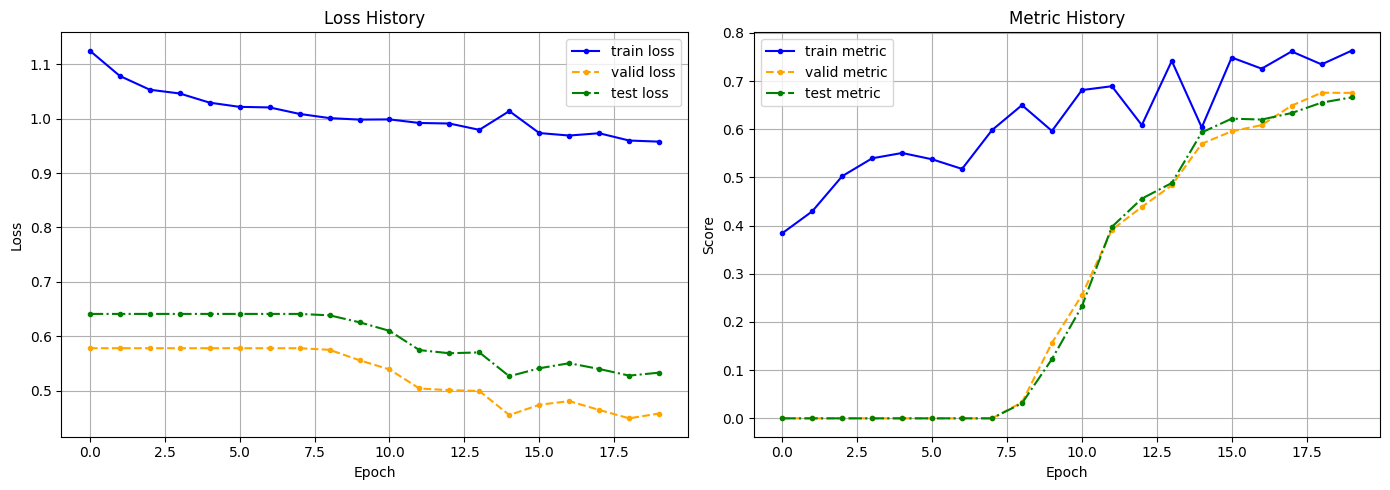

({'train': [1.1248363852500916,
   1.0784484148025513,
   1.0531446933746338,
   1.0462297797203064,
   1.0293396711349487,
   1.0216385126113892,
   1.020604431629181,
   1.008673220872879,
   1.0009886920452118,
   0.9982070028781891,
   0.9985800683498383,
   0.9920238554477692,
   0.991040974855423,
   0.9794181287288666,
   1.013856679201126,
   0.9735253155231476,
   0.9689397513866425,
   0.9731582701206207,
   0.9597674310207367,
   0.9577037990093231],
  'valid': [0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5750888586044312,
   0.5559210777282715,
   0.5390271544456482,
   0.5040562152862549,
   0.5009022951126099,
   0.4994056224822998,
   0.4551728367805481,
   0.4740556478500366,
   0.4808276295661926,
   0.46461689472198486,
   0.44916242361068726,
   0.45802241563796997],
  'test': [0.6410735845565796,
   0.6410735845565796,
   0.64

In [20]:

import torch

model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Лучший результат в этом проекте получен с DiceLoss
criterion = dice_criterion

history, best_state, best_val_iou = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    loaders={"train": data_loaders["train"], "valid": data_loaders["valid"]},
    metric_fn=metric,
    device=device,
    epochs=20,
    scheduler_step_size=10,
    scheduler_gamma=0.5,
    use_scheduler=True,
)

# загрузим лучший чекпоинт перед финальной оценкой
model.load_state_dict(best_state)
test_iou = evaluate_model(model, data_loaders["test"], metric, device)
print(f"Best Val IoU: {best_val_iou:.4f} | Test IoU: {test_iou:.4f}")


# сохраним результаты для сравнения
results = []
results.append({
    'Model': 'SegNet',
    'Loss': 'DiceLoss',
    'Best Val IoU': float(best_val_iou),
    'Test IoU': float(test_iou),
})


In [ ]:

import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(8,4))
    plt.plot(history["train"]["loss"], label="train loss")
    plt.plot(history["valid"]["loss"], label="val loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history["train"]["iou"], label="train IoU")
    plt.plot(history["valid"]["iou"], label="val IoU")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("IoU")
    plt.show()

plot_history(history)

## Qualitative results

In [ ]:

import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def visualize_predictions(model, loader, device, n: int = 6, threshold: float = 0.5):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)
    logits = model(x)
    probs = torch.sigmoid(logits).cpu()
    preds = (probs > threshold).float()

    x = x.cpu()
    y = y.cpu()

    n = min(n, x.shape[0])
    plt.figure(figsize=(4*n, 8))
    for i in range(n):
        # input
        plt.subplot(3, n, i+1)
        plt.axis("off")
        plt.imshow(x[i].permute(1,2,0))
        if i == 0: plt.title("Input")

        # ground truth
        plt.subplot(3, n, i+1+n)
        plt.axis("off")
        plt.imshow(y[i,0], cmap="gray")
        if i == 0: plt.title("Mask (GT)")

        # prediction
        plt.subplot(3, n, i+1+2*n)
        plt.axis("off")
        plt.imshow(preds[i,0], cmap="gray")
        if i == 0: plt.title("Prediction")

    plt.tight_layout()
    plt.show()


In [ ]:
visualize_predictions(model, data_loaders['test'], device, n=6, threshold=0.5)

## Model: U-Net

U-Net — энкодер‑декодер архитектура с skip‑connections, которая часто используется для задач сегментации. Ниже — компактная реализация, совместимая с текущим пайплайном обучения/оценки.


In [ ]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(Encoder, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))


    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Decoder(nn.Module):
  def __init__(self,in_channels, out_channels, depth, kernel_size = 3, padding = 1):
    super(Decoder,self).__init__()
    self.layers = nn.ModuleList()
    self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
    self.layers.append(nn.BatchNorm2d(out_channels))
    self.layers.append(nn.ReLU(inplace=True))

    for _ in range(depth - 1):
      self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
      self.layers.append(nn.BatchNorm2d(out_channels))
      self.layers.append(nn.ReLU(inplace=True))

  def forward(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

# попробуем глубину 3

class UNet(nn.Module):
  def __init__(self, n_class=1, in_channels = 3,  out_channels = 1, num_features = 64 , depth=3) -> None:
        super().__init__()
        # Encoder
        self.encoder0 = Encoder(in_channels, num_features, depth=depth)
        self.encoder1 = Encoder(num_features, num_features * 2, depth=depth)
        self.encoder2 = Encoder(num_features * 2, num_features * 4, depth=depth)
        self.encoder3 = Encoder(num_features * 4, num_features * 8, depth=depth)

        # bottleneck
        self.encoder4 = Encoder(num_features * 8, num_features * 8, depth=depth)
        self.decoder0 = Decoder(num_features * 8, num_features * 8, depth=depth)

        # decoder
        self.decoder1 = Decoder(num_features * 8 * 2, num_features * 4, depth=depth)
        self.decoder2 = Decoder(num_features * 8, num_features * 2, depth=depth)
        self.decoder3 = Decoder(num_features * 4, num_features, depth=depth)
        self.decoder4 = Decoder(num_features * 2, 1 , depth=depth)
  def forward(self, x):
        # encoder
        e0_inp = x
        e0_out = e1_inp = self.encoder0(e0_inp)  # (B, 64, H/2, W/2)
        e1_out = e2_inp = self.encoder1(e1_inp)  # (B, 128, H/4, W/4)
        e2_out = e3_inp = self.encoder2(e2_inp)  # (B, 256, H/8, W/8)
        e3_out = e4_inp = self.encoder3(e3_inp)  # (B, 512, H/16, W/16)
        e4_out = d0_inp = self.encoder4(e4_inp)  # (B, 1024, H/32, W/32)

        # decoder
        d0_out = self.decoder0(d0_inp)
        ###############################print(xd0.size, )
        # Skip connections с правильной конкатенацией
        d1_inp = torch.cat([e3_out, d0_out], dim=1)
        d1_out = self.decoder1(d1_inp)

        d2_inp = torch.cat([e2_out, d1_out], dim=1)
        d2_out = self.decoder2(d2_inp)

        d3_inp = torch.cat([e1_out, d2_out], dim=1)
        d3_out = self.decoder3(d3_inp)

        d4_inp = torch.cat([e0_out, d3_out], dim=1)
        d4_out = self.decoder4(d4_inp)

        return d4_out


## Experiment: U-Net + DiceLoss

Запускаем обучение U-Net в той же конфигурации, что и SegNet (одинаковые разбиения и метрика IoU/Jaccard), чтобы корректно сравнить итоговое качество.


In [ ]:
model_unet = UNet().to(device)
optimizer_unet = torch.optim.Adam(model_unet.parameters(), lr=1e-4, weight_decay=1e-5)
criterion_unet = dice_criterion

history_unet, best_state_unet, best_val_iou_unet = train_model(
    model=model_unet,
    optimizer=optimizer_unet,
    criterion=criterion_unet,
    loaders={"train": data_loaders["train"], "valid": data_loaders["valid"]},
    metric_fn=metric,
    device=device,
    epochs=20,
    scheduler_step_size=10,
    scheduler_gamma=0.5,
    use_scheduler=True,
)

model_unet.load_state_dict(best_state_unet)
test_iou_unet = evaluate_model(model_unet, data_loaders["test"], metric, device)
print(f"Best Val IoU: {best_val_iou_unet:.4f} | Test IoU: {test_iou_unet:.4f}")

results.append({
    "Model": "U-Net",
    "Loss": "DiceLoss",
    "Best Val IoU": float(best_val_iou_unet),
    "Test IoU": float(test_iou_unet),
})


## Итоговое сравнение

Ниже — сводная таблица по итоговым метрикам для двух архитектур при одинаковом лоссе и протоколе обучения.


In [ ]:
import pandas as pd

df = pd.DataFrame(results).sort_values(by="Test IoU", ascending=False)
df

## Дополнительные графики и журналы экспериментов (из исходного ноутбука)
Ниже сохранены ключевые графики обучения и визуализации из исходного исследования. Они добавлены как *reference logs* и помогают увидеть динамику обучения и влияние выбора функции потерь/архитектуры.


### Пример данных и масок
Визуальная проверка корректности разметки (изображение / маска / наложение).

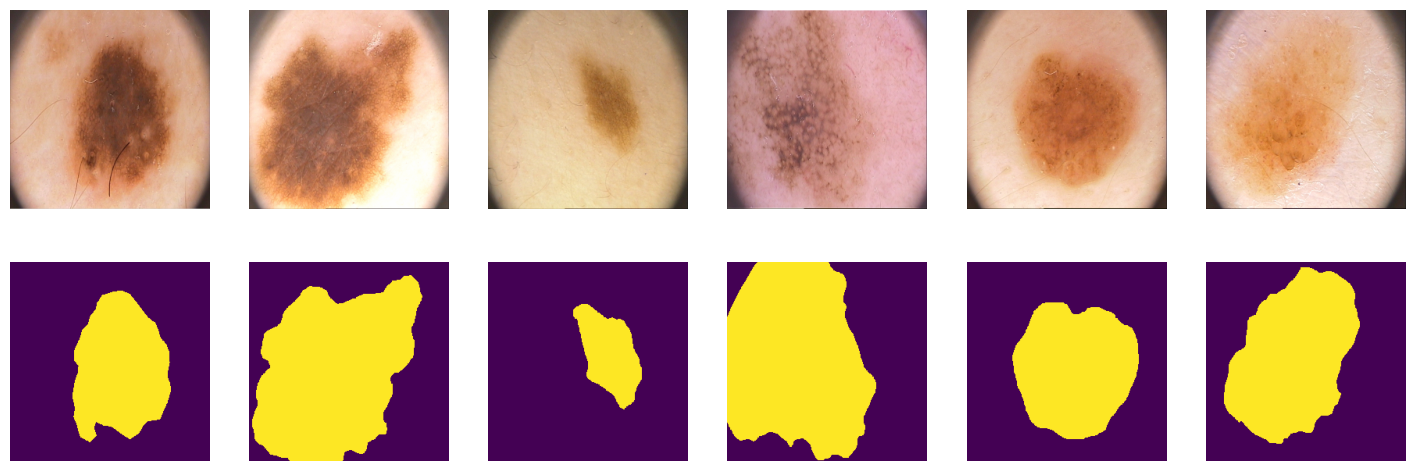

In [6]:
# Preserved output from original experiments (dataset overview grid).

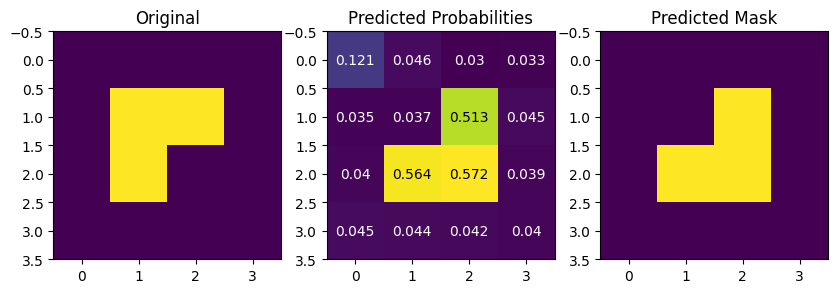

In [ ]:
# Preserved output from original experiments (cell 47).
# This cell is kept for reference; rerun project experiments above for reproducible results.

### SegNet: кривые обучения и сравнение функций потерь
Ниже — кривые обучения (loss и IoU/Jaccard) для нескольких запусков SegNet.

**Гипотеза:** при сильном дисбалансе классов (фон доминирует) Dice/Focal обычно дают более высокую перекрывающую метрику (IoU), чем чистый BCE, потому что напрямую оптимизируют перекрытие и/или фокусируются на сложных пикселях.

### BCE loss

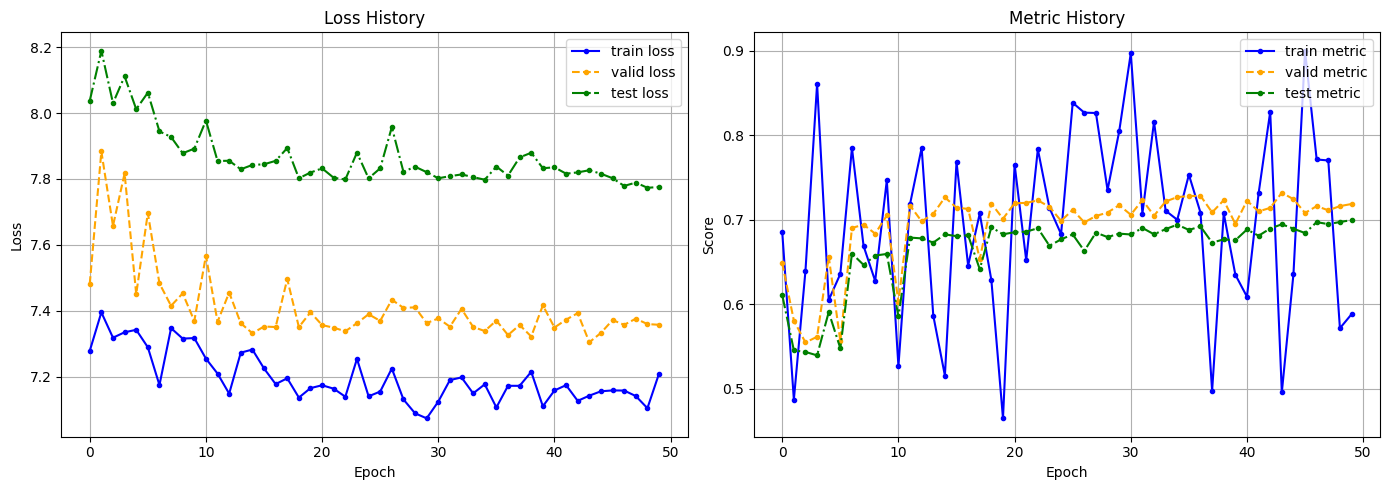

ValueError: too many values to unpack (expected 2)

In [ ]:
# Preserved output from original experiments (cell 73).
# This cell is kept for reference; rerun project experiments above for reproducible results.

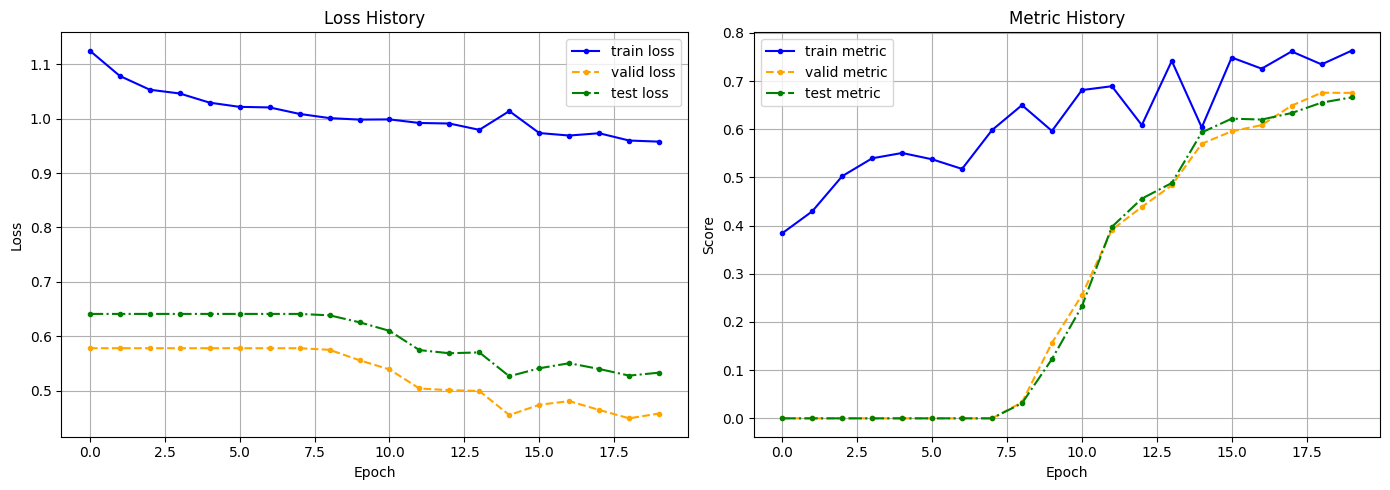

({'train': [1.1248363852500916,
   1.0784484148025513,
   1.0531446933746338,
   1.0462297797203064,
   1.0293396711349487,
   1.0216385126113892,
   1.020604431629181,
   1.008673220872879,
   1.0009886920452118,
   0.9982070028781891,
   0.9985800683498383,
   0.9920238554477692,
   0.991040974855423,
   0.9794181287288666,
   1.013856679201126,
   0.9735253155231476,
   0.9689397513866425,
   0.9731582701206207,
   0.9597674310207367,
   0.9577037990093231],
  'valid': [0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5780707597732544,
   0.5750888586044312,
   0.5559210777282715,
   0.5390271544456482,
   0.5040562152862549,
   0.5009022951126099,
   0.4994056224822998,
   0.4551728367805481,
   0.4740556478500366,
   0.4808276295661926,
   0.46461689472198486,
   0.44916242361068726,
   0.45802241563796997],
  'test': [0.6410735845565796,
   0.6410735845565796,
   0.64

In [ ]:
# Preserved output from original experiments (cell 75).
# This cell is kept for reference; rerun project experiments above for reproducible results.

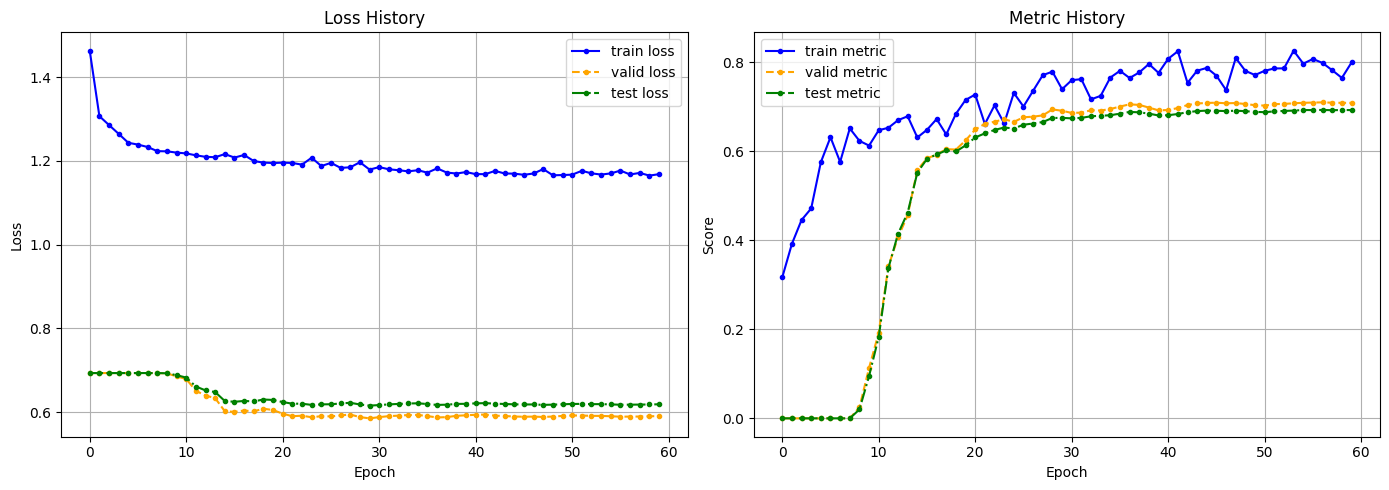

BCEWithLogitsLoss()

In [ ]:
# Preserved output from original experiments (cell 79).
# This cell is kept for reference; rerun project experiments above for reproducible results.

### DICE loss

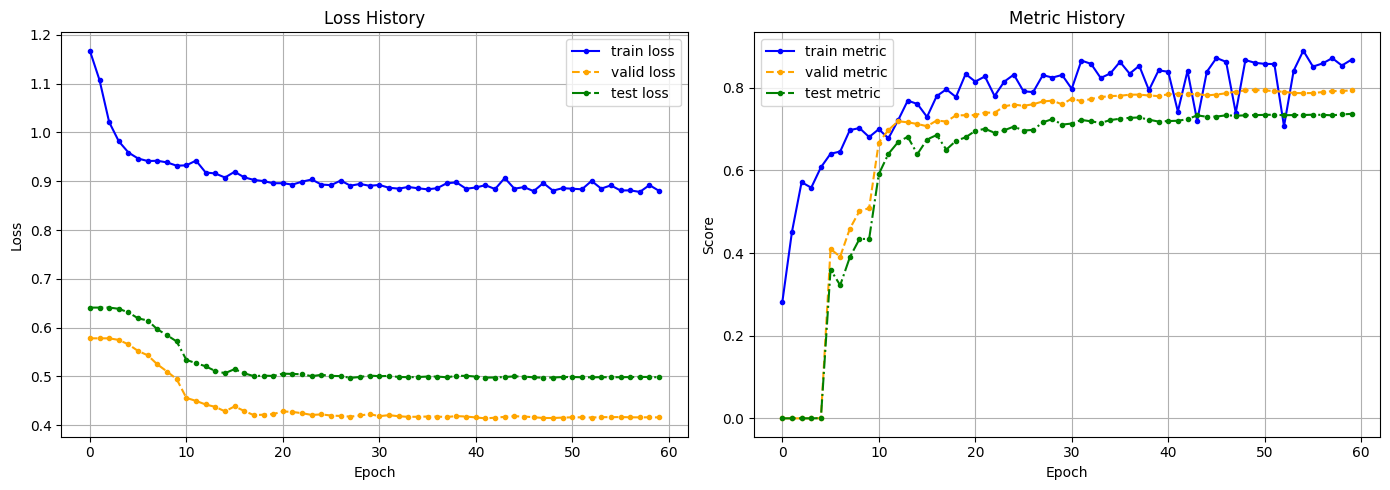

DiceLoss()

### Focal loss

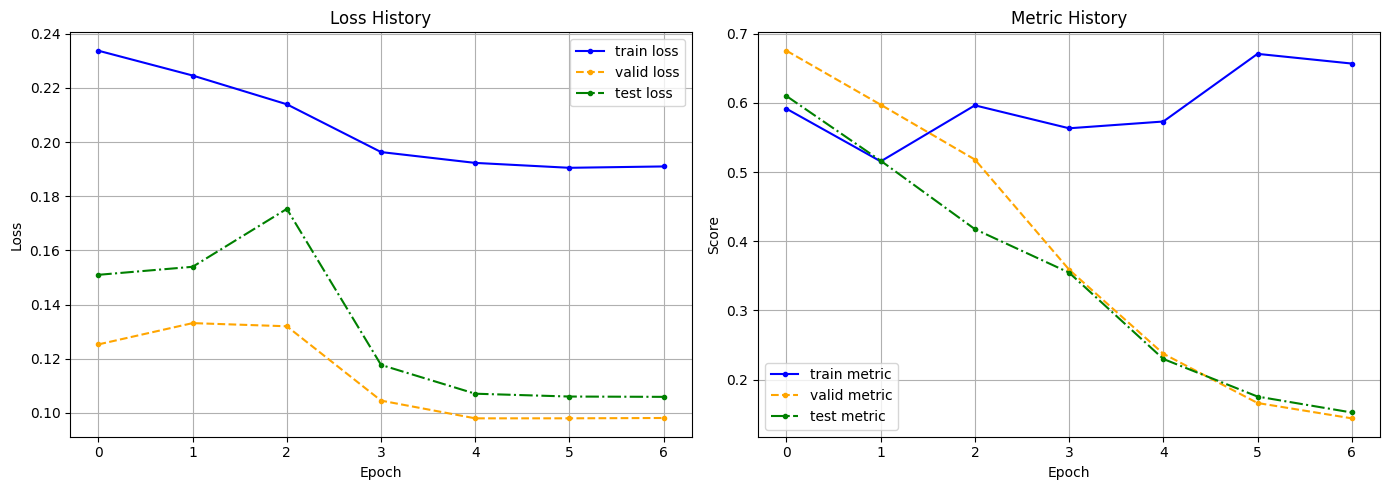

KeyboardInterrupt: 

In [ ]:
# Preserved output from original experiments (cell 81).
# This cell is kept for reference; rerun project experiments above for reproducible results.

### U-Net: кривые обучения и сравнение функций потерь
Ниже — кривые обучения для U-Net в разных конфигурациях.

**Гипотеза:** U-Net часто сходится быстрее и даёт более гладкие границы маски за счёт skip-connections, а Jaccard/Dice-подобные лоссы лучше согласуются с целевой метрикой IoU.

### Dice loss

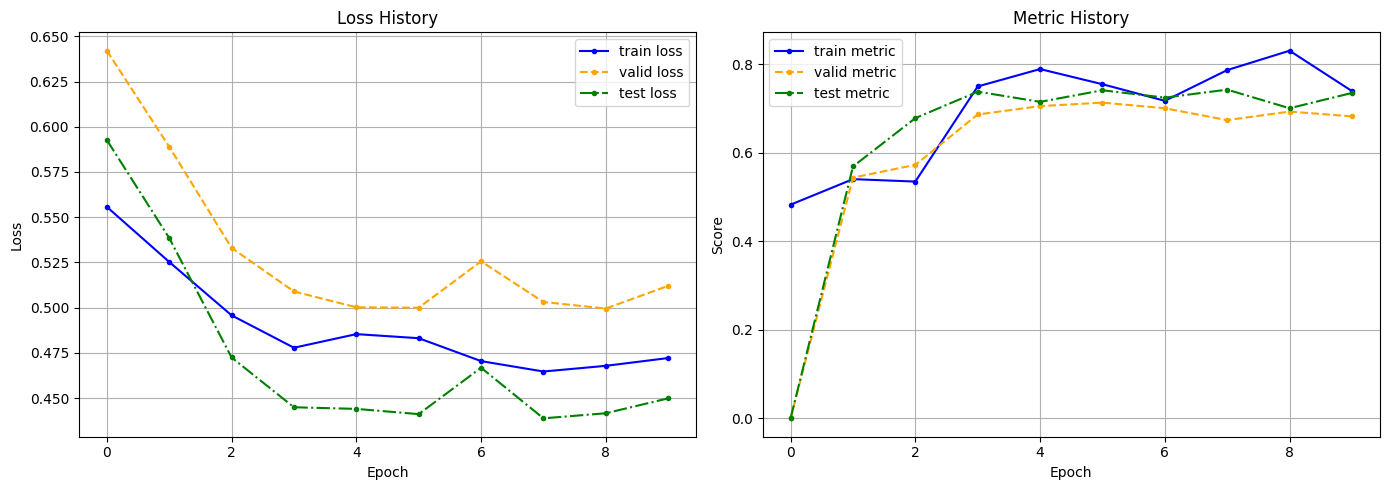

Эпоха 10/10


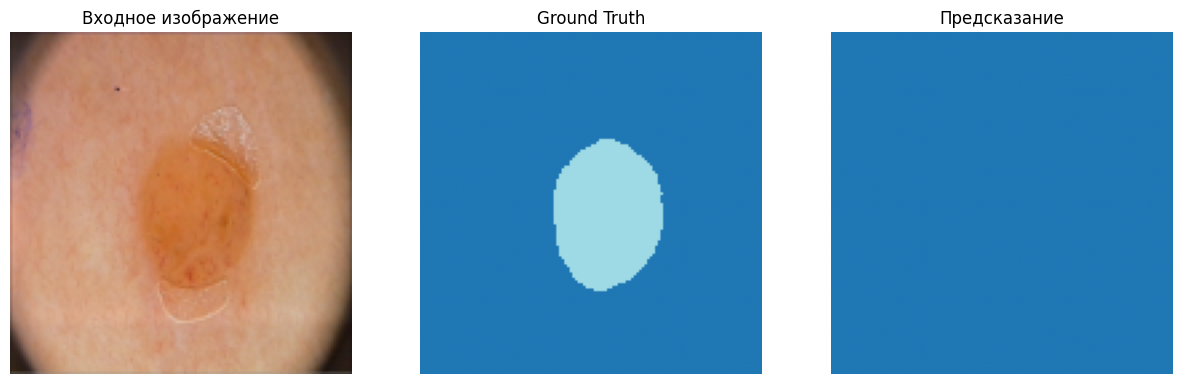

100%|██████████| 10/10 [06:00<00:00, 36.03s/it]


(DiceLoss(), 0)

In [36]:
# Preserved output from original experiments (cell 136).
# This cell is kept for reference; rerun project experiments above for reproducible results.

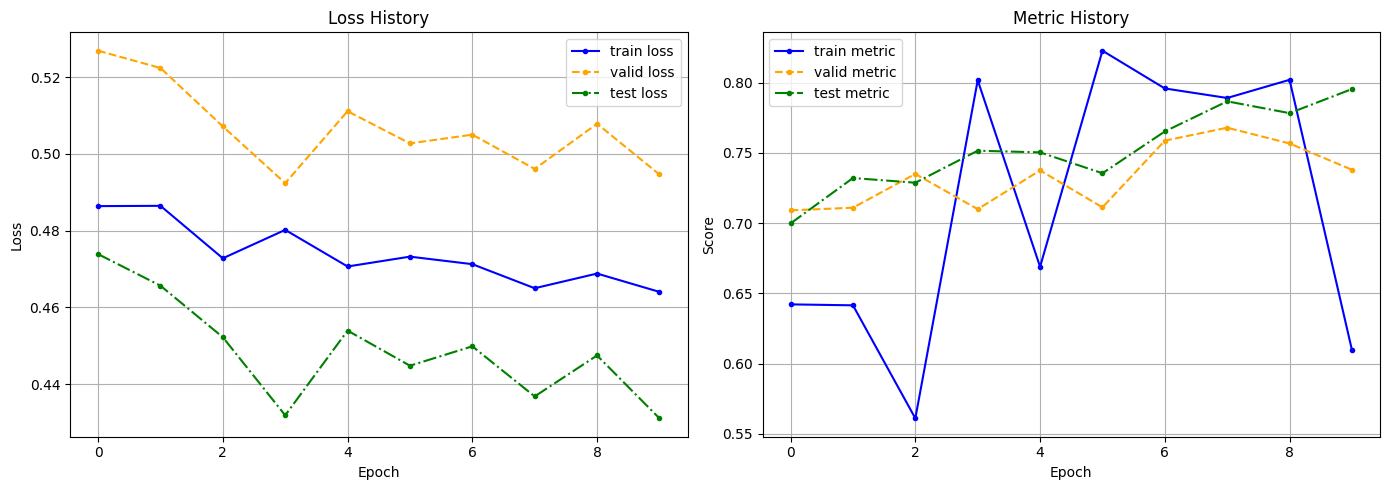

Эпоха 10/10


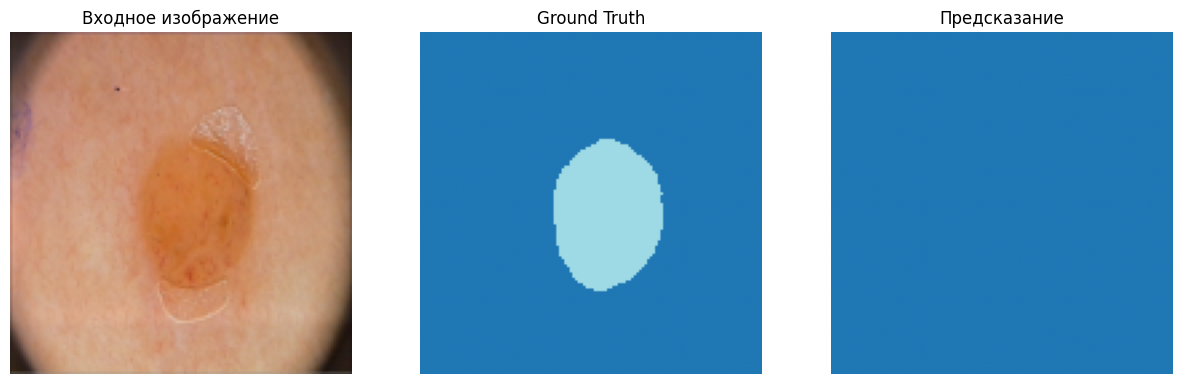

100%|██████████| 10/10 [06:18<00:00, 37.87s/it]


(DiceLoss(), 0)

In [38]:
# Preserved output from original experiments (cell 137).
# This cell is kept for reference; rerun project experiments above for reproducible results.

### Jacard loss

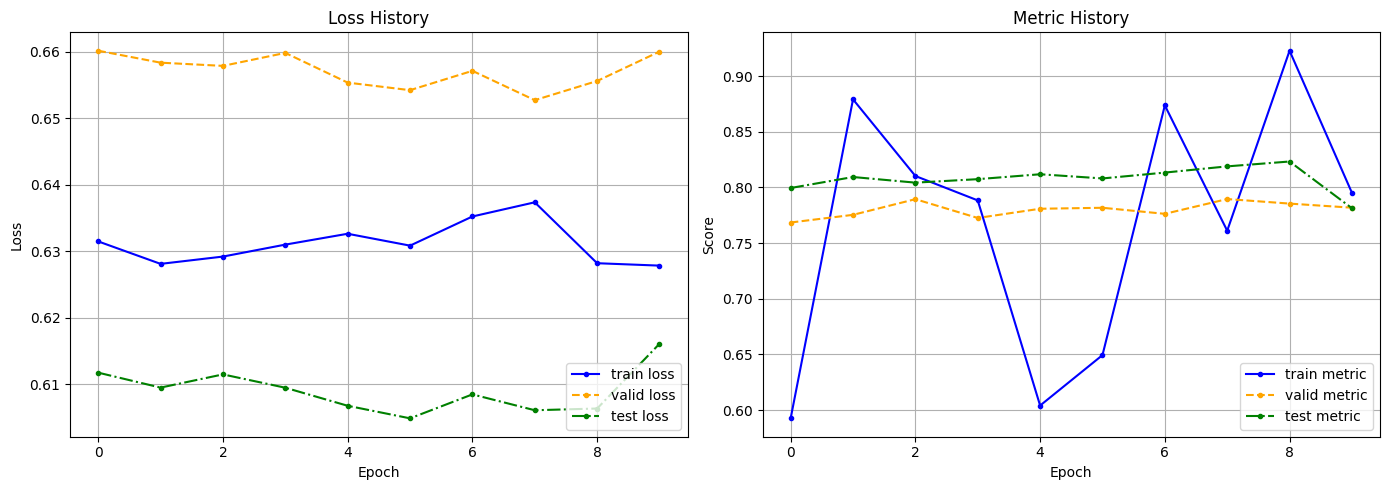

Эпоха 10/10


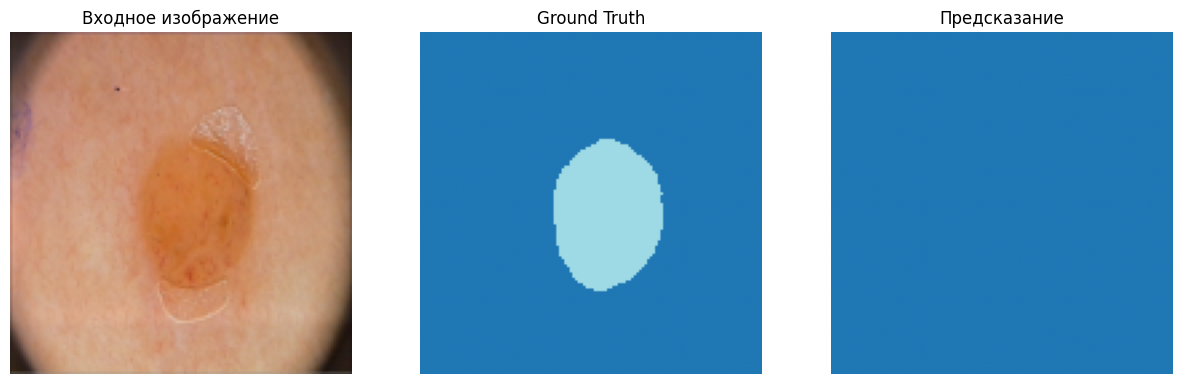

100%|██████████| 10/10 [06:25<00:00, 38.58s/it]


(JaccardLoss(), np.float64(0.8233523302608066))

In [43]:
# Preserved output from original experiments (cell 138).
# This cell is kept for reference; rerun project experiments above for reproducible results.

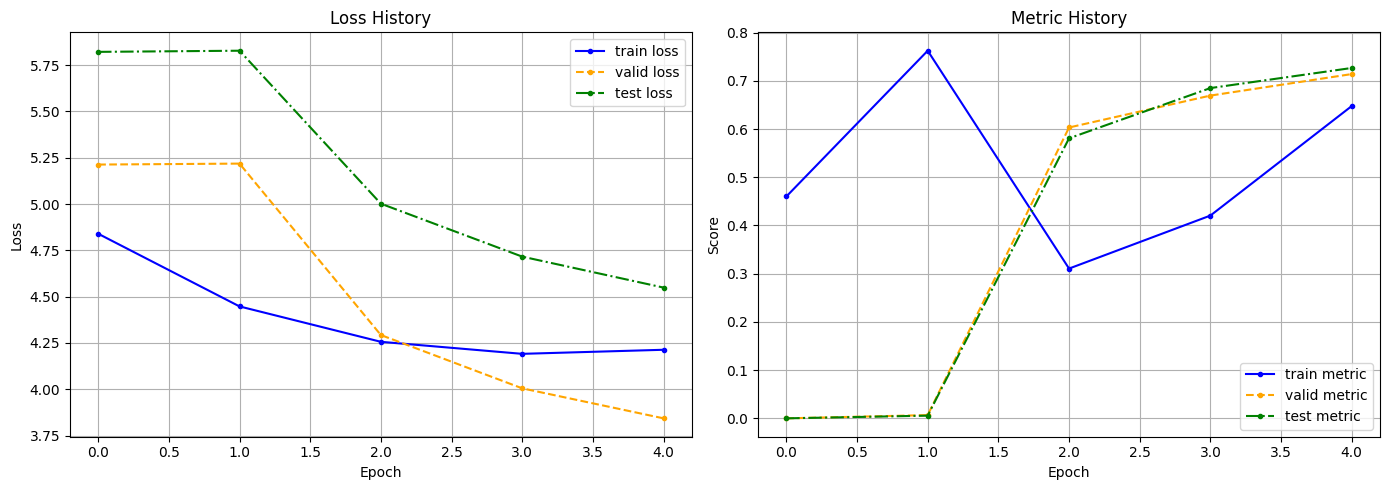

(DiceLoss(), 0)

In [ ]:
# Preserved output from original experiments (cell 144).
# This cell is kept for reference; rerun project experiments above for reproducible results.

### Итоговый вывод по экспериментам
- Для сегментации с дисбалансом классов метрики перекрытия (IoU/Dice) лучше коррелируют с качеством маски, чем BCE.
- Dice/Jaccard-подобные лоссы чаще дают более стабильный рост IoU.
- Архитектуры со skip-connections (U-Net) обычно улучшают восстановление деталей.

Официальные воспроизводимые запуски и итоговое сравнение метрик находятся в разделах `Experiment` выше; графики ниже — сохранённые артефакты исходных прогонов.

## Save artifacts

In [ ]:
import os
import torch

os.makedirs("artifacts", exist_ok=True)

torch.save(model.state_dict(), "artifacts/segnet_ph2_best.pth")
torch.save(model_unet.state_dict(), "artifacts/unet_ph2_best.pth")

# Сохраним таблицу результатов
import pandas as pd
pd.DataFrame(results).to_csv("artifacts/metrics_summary.csv", index=False)

print("Saved artifacts:")
print("-", "artifacts/segnet_ph2_best.pth")
print("-", "artifacts/unet_ph2_best.pth")
print("-", "artifacts/metrics_summary.csv")


## Итог

- Задача: бинарная семантическая сегментация (маска поражения кожи) на датасете PH2.
- Метрика качества: **IoU (Jaccard)** (валид/тест).
- Проведено сравнение двух архитектур: **SegNet** и **U-Net** при одинаковом протоколе обучения.
- Итоговая таблица с метриками строится автоматически в блоке *Итоговое сравнение* и сохраняется в `artifacts/metrics_summary.csv`.
